<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/3_regression_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score,r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression


In [121]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/MachineLearning/main/placement.csv")

In [122]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [123]:
X=df.iloc[:,0].values.reshape(-1,1)
y=df.iloc[:,-1]

In [124]:
type(y)

pandas.core.series.Series

In [125]:
type(X)

numpy.ndarray

In [126]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [127]:
lr=LinearRegression()

In [128]:
lr.fit(X_train,y_train)

LinearRegression()

In [129]:
y_pred=lr.predict(X_test)

In [130]:
r2_score(y_test,y_pred)

0.7730984312051673

In [131]:
mean_absolute_error(y_test,y_pred)*100

23.150985393278372

In [132]:
mean_squared_error(y_test,y_pred)*100

8.417638361329656

In [133]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.2901316659954521)

In [134]:
#adjust r2 scopre

In [135]:
r2=r2_score(y_test,y_pred)
r2

0.7730984312051673

In [136]:
1-((1-r2)*(X_test.shape[0]-1))/(X_test.shape[0]-1-1)

0.7671273372895138

In [137]:
new_df=df.copy()

In [138]:
new_df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [139]:
new_df["random_feature"]=np.random.random(200)

In [140]:
new_df

,cgpa,package,random_feature
0,6.89,3.26,0.940800
1,5.12,1.98,0.393730
2,7.82,3.25,0.680170
3,7.42,3.67,0.625738
4,6.94,3.57,0.497130
...,...,...,...
195,6.93,2.46,0.018853
196,5.89,2.57,0.145800
197,7.21,3.24,0.205821
198,7.63,3.96,0.350005


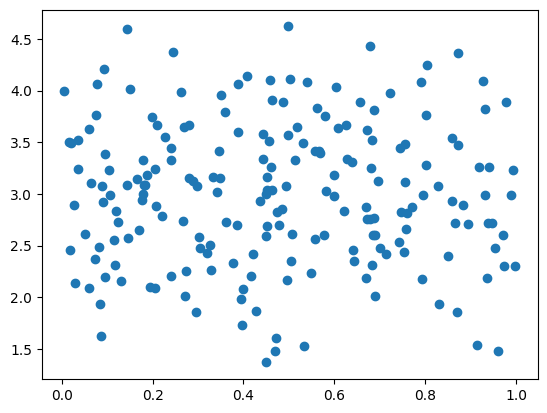

In [141]:
plt.scatter(new_df["random_feature"], new_df['package'])

In [142]:
new_df.head()

,cgpa,package,random_feature
0,6.89,3.26,0.940800
1,5.12,1.98,0.393730
2,7.82,3.25,0.680170
3,7.42,3.67,0.625738
4,6.94,3.57,0.497130


In [143]:
X=new_df.drop("package",axis=1)
y=new_df.drop(["cgpa","random_feature"],axis=1)

In [144]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [145]:
lr1=LinearRegression()

In [146]:
lr1.fit(X_train,y_train)

LinearRegression()

In [147]:
y_pred1=lr1.predict(X_test)

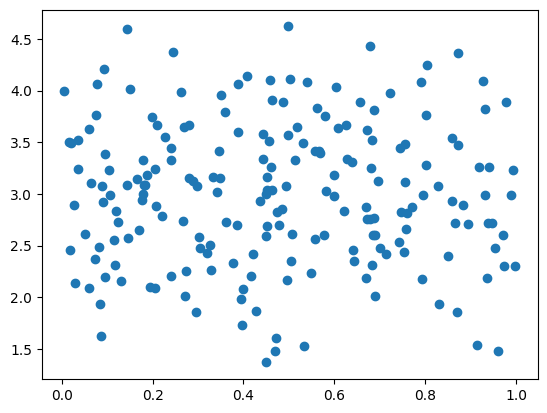

In [161]:
plt.scatter(new_df["random_feature"], new_df['package'])


In [149]:
r2=r2_score(y_test,y_pred1)

In [150]:
r2

0.77203542346216

In [151]:
1-((1-r2)*(X_test.shape[0]-1))/(X_test.shape[0]-1-1)

0.7660363556585327

In [152]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]


In [153]:
new_df2

,cgpa,iq,package
0,6.89,3.76,3.26
1,5.12,1.08,1.98
2,7.82,4.05,3.25
3,7.42,3.57,3.67
4,6.94,3.27,3.57
...,...,...,...
195,6.93,2.06,2.46
196,5.89,2.87,2.57
197,7.21,3.64,3.24
198,7.63,3.26,3.96


In [154]:
X=new_df2.iloc[:,0:2]
y=new_df2.iloc[:,-1]

In [155]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [156]:
lr=LinearRegression()

In [157]:
lr.fit(X_train,y_train)

LinearRegression()

In [158]:
y3=lr.predict(X_test)

In [159]:
y3

array([2.99395412, 3.02792575, 3.01012444, 2.31953527, 3.69493925,
       3.82742024, 3.05282176, 2.83831196, 3.12683654, 3.71171781,
       1.87499327, 2.20211108, 3.97950198, 2.51638601, 3.54793245,
       3.06711457, 2.25032359, 3.31465049, 2.39523297, 3.47812518,
       2.45724653, 2.97225596, 3.50309886, 2.8436849 , 3.24107597,
       2.0054676 , 1.35364007, 2.7905397 , 3.12589145, 2.42434958,
       3.64236389, 2.82025189, 3.56944953, 2.8525921 , 2.71967085,
       3.6261159 , 2.64045155, 3.05128109, 3.93434506, 2.96280509])

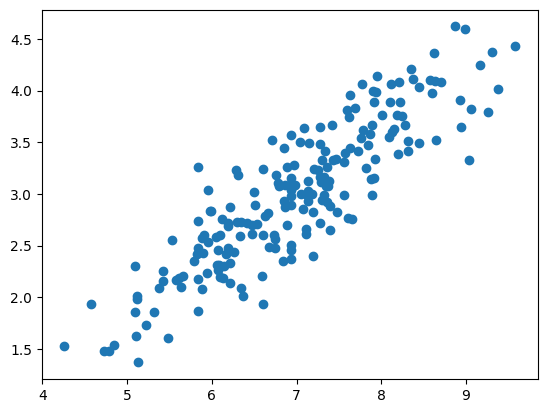

In [160]:
plt.scatter(new_df2["cgpa"], new_df2['package'])


In [162]:
r2=r2_score(y_test,y3)

In [163]:
r2

0.7783991606393328

In [164]:
1-((1-r2)*(X_test.shape[0]-1))/(X_test.shape[0]-1-1)

0.7725675596035257